In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

%matplotlib inline

# Carga e inspección inicial del dataset

En primer lugar se carga el dataset y se realiza una inspección inicial para entender:

- dimensiones del conjunto de datos,
- tipos de variables,
- posibles valores perdidos,
- estructura general del problema.

Dado que el dataset proviene de datos reales obtenidos mediante scraping, es necesario realizar una revisión previa antes del preprocesamiento y modelado.

In [2]:
df = pd.read_csv(
    "Práctica ML_airbnb-listings-extract.csv",
    sep=';',
    engine='python'
)

print(df.shape)

df.head()

(14780, 89)


,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,11210388,https://www.airbnb.com/rooms/11210388,20170306202425,2017-03-07,The Loft-Full Bath-Deck w/View,Loft in the Hill country 12-15 minutes directl...,This loft has a spectacular view of the hills ...,Loft in the Hill country 12-15 minutes directl...,none,This neighborhood is located in the hills west...,...,10.0,10.0,10.0,NaN,NaN,moderate,1.0,3.50,"30.3373609355,-97.8632766782","Host Is Superhost,Host Has Profile Pic,Host Id..."
1,17471131,https://www.airbnb.com/rooms/17471131,20170407214050,2017-04-08,"Claris I, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,10.0,8.0,10.0,HUTB-006721,NaN,super_strict_30,106.0,0.86,"41.3896829422,2.17262543017","Host Has Profile Pic,Requires License,Instant ..."
2,17584891,https://www.airbnb.com/rooms/17584891,20170407214050,2017-04-08,"Style Terrace Red, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,NaN,NaN,NaN,HUTB-007527,NaN,super_strict_30,106.0,NaN,"41.3930345489,2.16217327868","Host Has Profile Pic,Requires License,Instant ..."
3,5398030,https://www.airbnb.com/rooms/5398030,20170407214050,2017-04-08,Picasso Suite 1.4 Paseo de Gracia,Live like a local in Barcelona's most chic dis...,You wake up to the sun rising over Barcelona's...,Live like a local in Barcelona's most chic dis...,none,We're right in the heart of the chic L'Eixampl...,...,10.0,10.0,9.0,NaN,NaN,strict,24.0,1.09,"41.3969668101,2.1674178103","Host Has Profile Pic,Host Identity Verified,Re..."
4,18104606,https://www.airbnb.com/rooms/18104606,20170407214050,2017-04-08,Smart City Centre Apartment II,"Unique apartment in vibrant neighborhoods, car...","License: HUTB-005313 Charming apartment, locat...","Unique apartment in vibrant neighborhoods, car...",none,NaN,...,NaN,NaN,NaN,NaN,NaN,flexible,92.0,NaN,"41.3886851936,2.15514963616","Host Has Profile Pic,Host Identity Verified,Is..."


## Información general de variables

Se analiza la estructura del dataset utilizando `info()` para identificar:

- variables numéricas y categóricas,
- cantidad de valores nulos,
- posibles variables problemáticas,
- variables con un porcentaje elevado de missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14780 entries, 0 to 14779
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              14780 non-null  int64  
 1   Listing Url                     14780 non-null  object 
 2   Scrape ID                       14780 non-null  int64  
 3   Last Scraped                    14780 non-null  object 
 4   Name                            14779 non-null  object 
 5   Summary                         14189 non-null  object 
 6   Space                           10888 non-null  object 
 7   Description                     14774 non-null  object 
 8   Experiences Offered             14780 non-null  object 
 9   Neighborhood Overview           9134 non-null   object 
 10  Notes                           5644 non-null   object 
 11  Transit                         9066 non-null   object 
 12  Access                          

# Análisis exploratorio inicial

El siguiente paso consiste en analizar estadísticamente las variables numéricas del dataset, especialmente la variable objetivo `Price`.

El objetivo es detectar:

- posibles outliers,
- escalas de las variables,
- distribuciones anómalas,
- y valores que puedan requerir limpieza o transformación posterior.

In [4]:
df.describe()

,ID,Scrape ID,Host ID,Host Response Rate,Host Listings Count,Host Total Listings Count,Latitude,Longitude,Accommodates,Bathrooms,...,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Calculated host listings count,Reviews per Month
count,1.478000e+04,1.478000e+04,1.478000e+04,12881.000000,14777.000000,14777.000000,14780.000000,14780.000000,14780.000000,14725.000000,...,14780.000000,11476.000000,11454.000000,11460.000000,11443.000000,11460.000000,11440.000000,11439.000000,14776.000000,11618.000000
mean,1.028089e+07,2.017037e+13,3.608080e+07,94.823461,12.513636,12.513636,40.497626,-3.858041,3.277808,1.281732,...,22.632273,91.697978,9.416012,9.328883,9.621778,9.647033,9.532168,9.218201,9.486871,1.870014
std,5.564829e+06,5.667971e+08,3.425360e+07,15.215988,34.090223,34.090223,4.641387,14.123146,2.097291,0.658517,...,38.290244,8.989101,0.921938,0.989933,0.802736,0.767116,0.774527,0.950578,23.626014,1.867550
min,1.862800e+04,2.016010e+13,1.745300e+04,0.000000,0.000000,0.000000,-37.851182,-123.131344,1.000000,0.000000,...,0.000000,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.020000
25%,5.554732e+06,2.017041e+13,6.787360e+06,100.000000,1.000000,1.000000,40.409726,-3.707604,2.000000,1.000000,...,1.000000,89.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,1.000000,0.450000
50%,1.133492e+07,2.017041e+13,2.464875e+07,100.000000,2.000000,2.000000,40.419466,-3.700785,3.000000,1.000000,...,7.000000,94.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,2.000000,1.200000
75%,1.532631e+07,2.017041e+13,5.432919e+07,100.000000,6.000000,6.000000,40.430916,-3.684057,4.000000,1.000000,...,27.000000,98.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,5.000000,2.780000
max,1.910969e+07,2.017062e+13,1.247534e+08,100.000000,519.000000,519.000000,55.966912,153.371427,16.000000,8.000000,...,446.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,145.000000,17.210000


In [5]:
df["Price"].describe()

count    14763.000000
mean        73.561471
std         72.062050
min          9.000000
25%         34.000000
50%         55.000000
75%         86.000000
max        999.000000
Name: Price, dtype: float64

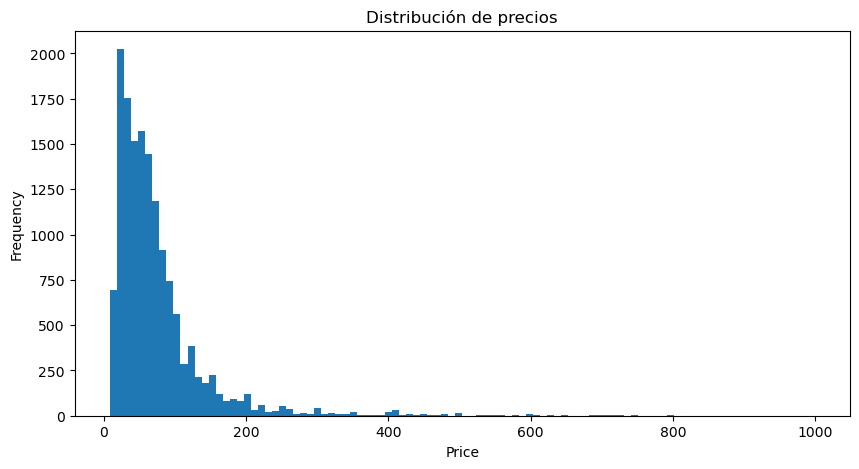

In [6]:
plt.figure(figsize=(10,5))

plt.hist(df["Price"].dropna(), bins=100)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribución de precios")

plt.show()

## Análisis de outliers

A partir de la distribución de precios se observa una fuerte asimetría positiva, con algunos valores extremadamente altos.

Para analizar mejor la presencia de posibles outliers se utilizará un boxplot sobre la variable objetivo `Price`.

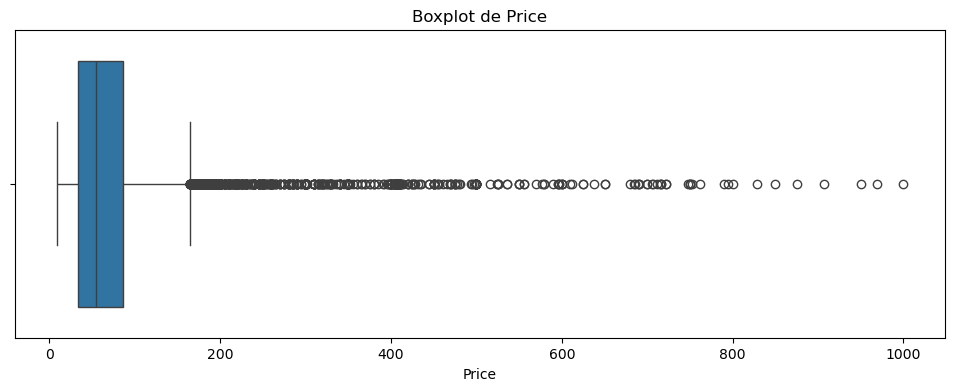

In [7]:
plt.figure(figsize=(12,4))

sns.boxplot(x=df["Price"])

plt.title("Boxplot de Price")

plt.show()

## Análisis de percentiles altos

Antes de eliminar posibles outliers se analizan distintos percentiles de la variable `Price` para entender mejor cómo se distribuyen los precios altos y evitar eliminar observaciones válidas del problema.

In [8]:
df["Price"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900    135.000
0.950    190.000
0.990    405.000
0.995    500.000
0.999    748.476
Name: Price, dtype: float64

## Tratamiento inicial de outliers

A partir del análisis de percentiles se observa que los precios superiores a 405 representan una fracción muy pequeña del dataset.

Con el objetivo de reducir el impacto de valores extremadamente altos sobre los modelos de regresión, se eliminarán observaciones con `Price > 405`.

Esta decisión permite mantener la mayor parte de los datos originales, evitando al mismo tiempo que unos pocos casos excepcionales distorsionen el entrenamiento.

In [9]:
df = df[df["Price"] <= 405]

print(df.shape)

(14619, 89)


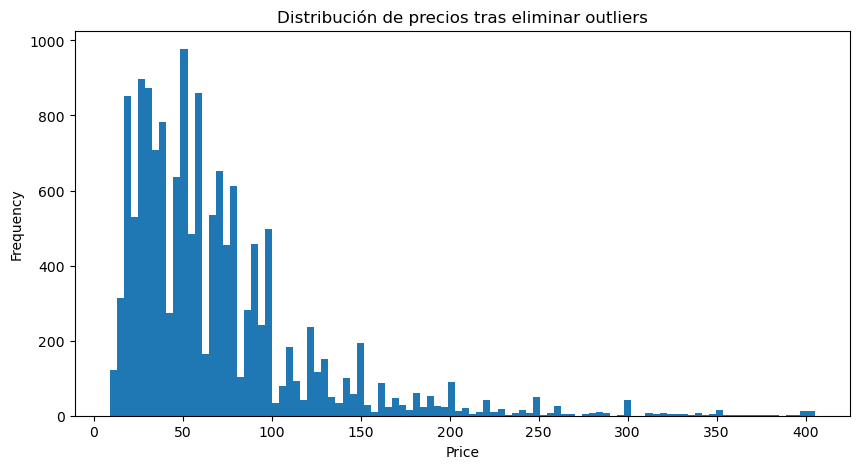

In [10]:
plt.figure(figsize=(10,5))

plt.hist(df["Price"], bins=100)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribución de precios tras eliminar outliers")

plt.show()

# División train/test

Antes de continuar con el preprocesamiento y modelado se divide el dataset en conjuntos de entrenamiento y test.

Esta separación permite evaluar correctamente la capacidad de generalización de los modelos y evitar problemas de data leakage.

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)

y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (11695, 88)
Test: (2924, 88)


# Análisis de valores nulos

Se analiza el porcentaje de valores nulos en cada variable para identificar columnas con poca información útil.

Las variables con un porcentaje muy elevado de missing values pueden introducir ruido y dificultar el entrenamiento de los modelos.

In [12]:
missing_percent = X_train.isnull().mean() * 100

missing_percent = missing_percent.sort_values(ascending=False)

missing_percent.head(20)

Has Availability         99.931595
Host Acceptance Rate     99.752031
Jurisdiction Names       98.546387
License                  97.571612
Square Feet              96.066695
Monthly Price            75.844378
Weekly Price             75.553655
Notes                    61.368106
Security Deposit         57.349295
Interaction              44.087217
Access                   42.967080
Cleaning Fee             40.897820
Transit                  38.247114
Neighborhood Overview    37.657118
Host About               35.365541
Neighbourhood            35.014964
House Rules              34.920906
Host Neighbourhood       25.917059
Space                    25.865755
Review Scores Value      22.009406
dtype: float64

## Eliminación inicial de variables

Se eliminan variables con:

- porcentaje extremadamente alto de valores nulos,
- posibles problemas de data leakage,
- o contenido textual libre difícil de utilizar dentro del alcance del curso.

El objetivo es reducir ruido y simplificar el problema antes del modelado.

In [13]:
columns_to_drop = [
    "ID",
    "Host ID",
    "Scrape ID",
    "Has Availability",
    "Host Acceptance Rate",
    "Jurisdiction Names",
    "License",
    "Square Feet",
    "Monthly Price",
    "Weekly Price",
    "Notes",
    "Interaction",
    "Transit",
    "Neighborhood Overview",
    "Host About",
    "House Rules"
]

X_train = X_train.drop(columns=columns_to_drop)

X_test = X_test.drop(columns=columns_to_drop)

print(X_train.shape)
print(X_test.shape)

(11695, 72)
(2924, 72)


# Análisis de tipos de variables

Después de la limpieza inicial se revisan nuevamente los tipos de variables disponibles para identificar:

- variables numéricas,
- variables categóricas,
- identificadores,
- URLs,
- y columnas potencialmente redundantes o poco útiles para el modelado.

In [14]:
X_train.dtypes.value_counts()

object     43
float64    19
int64      10
Name: count, dtype: int64

In [15]:
categorical_columns = X_train.select_dtypes(include=["object"]).columns

categorical_columns

Index(['Listing Url', 'Last Scraped', 'Name', 'Summary', 'Space',
       'Description', 'Experiences Offered', 'Access', 'Thumbnail Url',
       'Medium Url', 'Picture Url', 'XL Picture Url', 'Host URL', 'Host Name',
       'Host Since', 'Host Location', 'Host Response Time',
       'Host Thumbnail Url', 'Host Picture Url', 'Host Neighbourhood',
       'Host Verifications', 'Street', 'Neighbourhood',
       'Neighbourhood Cleansed', 'Neighbourhood Group Cleansed', 'City',
       'State', 'Zipcode', 'Market', 'Smart Location', 'Country Code',
       'Country', 'Property Type', 'Room Type', 'Bed Type', 'Amenities',
       'Calendar Updated', 'Calendar last Scraped', 'First Review',
       'Last Review', 'Cancellation Policy', 'Geolocation', 'Features'],
      dtype='object')

## Eliminación de variables textuales y URLs

Se eliminan variables relacionadas con:

- URLs,
- imágenes,
- texto libre extenso,
- y columnas con alta cardinalidad o poca utilidad práctica para el modelado.

Estas variables requerirían técnicas de procesamiento de texto más avanzadas, fuera del alcance de la práctica y del contenido trabajado durante el curso.

In [16]:
more_columns_to_drop = [
    "Listing Url",
    "Name",
    "Summary",
    "Space",
    "Description",
    "Thumbnail Url",
    "Medium Url",
    "Picture Url",
    "XL Picture Url",
    "Host URL",
    "Host Thumbnail Url",
    "Host Picture Url",
    "Street",
    "Geolocation"
]

X_train = X_train.drop(columns=more_columns_to_drop)

X_test = X_test.drop(columns=more_columns_to_drop)

print(X_train.shape)
print(X_test.shape)

(11695, 58)
(2924, 58)


In [17]:
categorical_columns = X_train.select_dtypes(include=["object"]).columns

categorical_columns

Index(['Last Scraped', 'Experiences Offered', 'Access', 'Host Name',
       'Host Since', 'Host Location', 'Host Response Time',
       'Host Neighbourhood', 'Host Verifications', 'Neighbourhood',
       'Neighbourhood Cleansed', 'Neighbourhood Group Cleansed', 'City',
       'State', 'Zipcode', 'Market', 'Smart Location', 'Country Code',
       'Country', 'Property Type', 'Room Type', 'Bed Type', 'Amenities',
       'Calendar Updated', 'Calendar last Scraped', 'First Review',
       'Last Review', 'Cancellation Policy', 'Features'],
      dtype='object')

## Eliminación de variables semiestructuradas

Se eliminan algunas variables compuestas por listas de texto semiestructuradas.

Aunque contienen información potencialmente útil, su procesamiento requeriría técnicas adicionales de parsing y feature engineering más avanzadas, fuera del alcance principal del curso y de la práctica.

In [18]:
final_columns_to_drop = [
    "Amenities",
    "Features",
    "Host Verifications"
]

X_train = X_train.drop(columns=final_columns_to_drop)

X_test = X_test.drop(columns=final_columns_to_drop)

print(X_train.shape)
print(X_test.shape)

(11695, 55)
(2924, 55)


# Análisis de cardinalidad en variables categóricas

Se analiza el número de categorías únicas presentes en las variables categóricas restantes.

Las variables con cardinalidad extremadamente alta pueden generar ruido, aumentar la dimensionalidad y dificultar el entrenamiento de algunos modelos.

In [19]:
categorical_columns = X_train.select_dtypes(include=["object"]).columns

cardinality = X_train[categorical_columns].nunique().sort_values(ascending=False)

cardinality

Access                          5809
Host Name                       2853
Host Since                      2059
First Review                    1590
Last Review                      735
Zipcode                          530
Host Location                    486
Neighbourhood Cleansed           434
Neighbourhood                    345
Host Neighbourhood               344
Smart Location                   219
City                             211
State                             86
Calendar Updated                  56
Neighbourhood Group Cleansed      48
Market                            40
Calendar last Scraped             37
Last Scraped                      34
Property Type                     22
Country                           16
Country Code                      16
Cancellation Policy                8
Bed Type                           5
Experiences Offered                5
Host Response Time                 4
Room Type                          3
dtype: int64

## Eliminación de variables con cardinalidad muy alta

Se eliminan algunas variables categóricas con cardinalidad extremadamente alta o relacionadas con fechas crudas.

Estas variables podrían aumentar significativamente la dimensionalidad y generar ruido en los modelos sin aportar capacidad predictiva proporcional.

In [20]:
high_cardinality_columns = [
    "Access",
    "Host Name",
    "Host Since",
    "First Review",
    "Last Review"
]

X_train = X_train.drop(columns=high_cardinality_columns)

X_test = X_test.drop(columns=high_cardinality_columns)

print(X_train.shape)
print(X_test.shape)

(11695, 50)
(2924, 50)


# Análisis de correlación

Se analiza la correlación entre variables numéricas para detectar posibles relaciones fuertes y redundancias.

Variables altamente correlacionadas pueden introducir multicolinealidad y aumentar innecesariamente la complejidad del modelo.

In [21]:
numeric_columns = X_train.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_columns.corr()

correlation_matrix

,Host Response Rate,Host Listings Count,Host Total Listings Count,Latitude,Longitude,Accommodates,Bathrooms,Bedrooms,Beds,Security Deposit,...,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Calculated host listings count,Reviews per Month
Host Response Rate,1.000000,-0.006587,-0.006587,-0.017811,0.001861,0.070410,-0.028064,0.013837,0.039315,-0.009029,...,0.132923,0.096766,0.078868,0.104811,0.092883,0.085084,0.055948,0.094963,-0.026615,0.182906
Host Listings Count,-0.006587,1.000000,1.000000,0.003372,0.049678,0.224255,0.221296,0.182066,0.168405,0.028217,...,-0.115556,-0.153816,-0.115534,-0.066244,-0.245981,-0.221287,-0.058796,-0.150640,0.918139,-0.151016
Host Total Listings Count,-0.006587,1.000000,1.000000,0.003372,0.049678,0.224255,0.221296,0.182066,0.168405,0.028217,...,-0.115556,-0.153816,-0.115534,-0.066244,-0.245981,-0.221287,-0.058796,-0.150640,0.918139,-0.151016
Latitude,-0.017811,0.003372,0.003372,1.000000,-0.505552,0.011414,-0.002068,-0.005847,0.002575,0.031888,...,0.013828,-0.015712,-0.017362,-0.015229,-0.003682,-0.006926,-0.020891,-0.015818,-0.000743,0.012484
Longitude,0.001861,0.049678,0.049678,-0.505552,1.000000,0.016183,0.022887,0.035904,0.027292,-0.034067,...,-0.031952,-0.013497,-0.015600,0.007262,-0.017504,-0.021625,-0.024275,-0.015541,0.051000,-0.014547
Accommodates,0.070410,0.224255,0.224255,0.011414,0.016183,1.000000,0.391806,0.710555,0.833162,0.187008,...,0.062789,-0.068933,-0.066427,-0.030645,-0.089816,-0.064954,0.014388,-0.071936,0.257304,0.030192
Bathrooms,-0.028064,0.221296,0.221296,-0.002068,0.022887,0.391806,1.000000,0.482865,0.442520,0.189114,...,-0.075912,0.007826,0.004958,0.006144,-0.050027,-0.052346,0.009070,-0.001577,0.280566,-0.085716
Bedrooms,0.013837,0.182066,0.182066,-0.005847,0.035904,0.710555,0.482865,1.000000,0.717252,0.223171,...,-0.043539,-0.003968,-0.009087,-0.004825,-0.044533,-0.021423,-0.029715,-0.022978,0.223209,-0.067732
Beds,0.039315,0.168405,0.168405,0.002575,0.027292,0.833162,0.442520,0.717252,1.000000,0.181475,...,0.020153,-0.050316,-0.055760,-0.022183,-0.065565,-0.046605,-0.021506,-0.053657,0.218157,-0.026924
Security Deposit,-0.009029,0.028217,0.028217,0.031888,-0.034067,0.187008,0.189114,0.223171,0.181475,1.000000,...,-0.120983,0.061672,0.060972,0.059964,0.026704,0.029241,0.021425,0.025793,0.026527,-0.143567


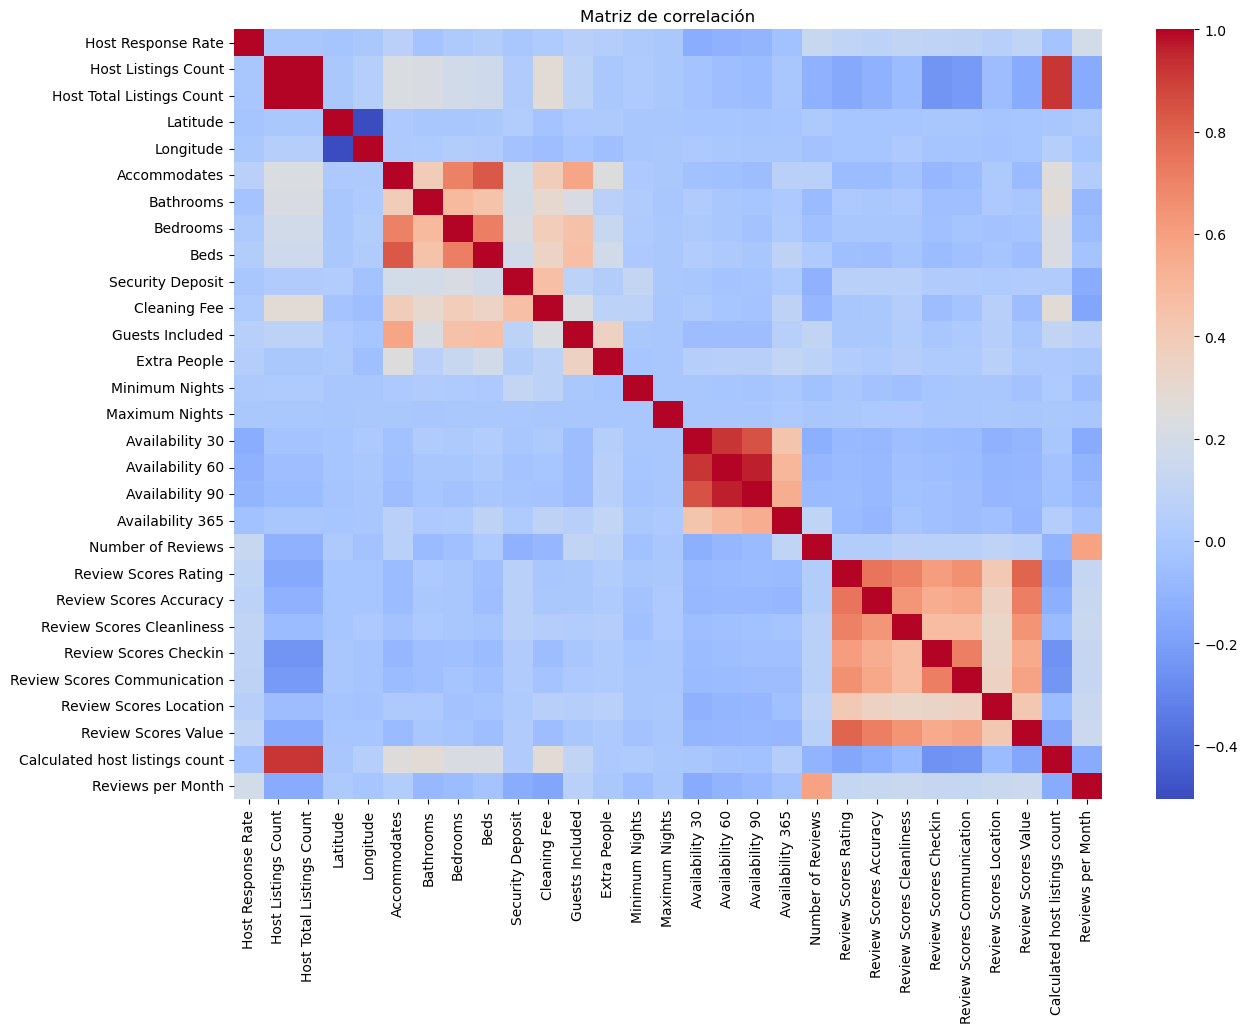

In [22]:
plt.figure(figsize=(14,10))

sns.heatmap(correlation_matrix, cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()

# Identificación de multicolinealidad

In [23]:
corr_matrix = numeric_columns.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.85)
]

high_corr

['Host Total Listings Count',
 'Availability 60',
 'Availability 90',
 'Calculated host listings count']

## Eliminación de variables altamente correlacionadas

A partir del análisis de correlación se identificaron algunas variables con multicolinealidad fuerte.

Para reducir redundancia y simplificar el modelo se eliminan variables altamente correlacionadas que representan información muy similar.

In [24]:
correlated_columns_to_drop = [
    "Host Total Listings Count",
    "Calculated host listings count",
    "Availability 60",
    "Availability 90"
]

X_train = X_train.drop(columns=correlated_columns_to_drop)

X_test = X_test.drop(columns=correlated_columns_to_drop)

print(X_train.shape)
print(X_test.shape)

(11695, 46)
(2924, 46)


# Revisión final de valores nulos

Después de la limpieza y selección de variables se revisan nuevamente los valores nulos restantes.

El objetivo es identificar qué variables todavía requieren imputación antes del modelado.

In [25]:
missing_percent = X_train.isnull().mean() * 100

missing_percent = missing_percent[missing_percent > 0]

missing_percent.sort_values(ascending=False)

Security Deposit                57.349295
Cleaning Fee                    40.897820
Neighbourhood                   35.014964
Host Neighbourhood              25.917059
Review Scores Value             22.009406
Review Scores Location          22.009406
Review Scores Checkin           22.000855
Review Scores Accuracy          21.932450
Review Scores Cleanliness       21.889696
Review Scores Communication     21.889696
Review Scores Rating            21.795639
Reviews per Month               20.880718
Host Response Time              12.518170
Host Response Rate              12.518170
Neighbourhood Group Cleansed     6.618213
Zipcode                          3.368961
State                            0.949124
Bathrooms                        0.359128
Beds                             0.333476
Market                           0.324925
Host Location                    0.316375
Bedrooms                         0.171013
Host Listings Count              0.025652
City                             0

# Tratamiento final de valores nulos

Se realiza el tratamiento final de valores nulos mediante:

- eliminación de variables con exceso de missing values,
- imputación numérica utilizando la mediana,
- e imputación categórica utilizando la moda.

Estas estrategias permiten conservar información útil reduciendo al mismo tiempo la pérdida de datos.

In [26]:
X_train = X_train.drop(columns=["Security Deposit"])

X_test = X_test.drop(columns=["Security Deposit"])

print(X_train.shape)
print(X_test.shape)

(11695, 45)
(2924, 45)


## Imputación de variables numéricas

Las variables numéricas restantes se imputan utilizando la mediana, debido a su robustez frente a outliers.

En el caso de `Cleaning Fee`, los valores nulos se reemplazan por 0, asumiendo que muchos anuncios no incluyen un costo de limpieza adicional.

In [27]:
numeric_columns = X_train.select_dtypes(include=["int64", "float64"]).columns

# imputación especial para Cleaning Fee
X_train["Cleaning Fee"] = X_train["Cleaning Fee"].fillna(0)
X_test["Cleaning Fee"] = X_test["Cleaning Fee"].fillna(0)

# restantes numéricas
numeric_columns = numeric_columns.drop("Cleaning Fee")

for col in numeric_columns:
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

In [28]:
X_train.select_dtypes(include=["int64", "float64"]).isnull().sum().sort_values(ascending=False)

Host Response Rate             0
Host Listings Count            0
Review Scores Value            0
Review Scores Location         0
Review Scores Communication    0
Review Scores Checkin          0
Review Scores Cleanliness      0
Review Scores Accuracy         0
Review Scores Rating           0
Number of Reviews              0
Availability 365               0
Availability 30                0
Maximum Nights                 0
Minimum Nights                 0
Extra People                   0
Guests Included                0
Cleaning Fee                   0
Beds                           0
Bedrooms                       0
Bathrooms                      0
Accommodates                   0
Longitude                      0
Latitude                       0
Reviews per Month              0
dtype: int64

## Imputación de variables categóricas

Las variables categóricas restantes se imputan utilizando la moda (valor más frecuente).

Esta estrategia permite conservar observaciones y completar valores faltantes utilizando la categoría más frecuente de cada variable.

In [29]:
categorical_columns = X_train.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    mode_value = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

In [30]:
X_train.isnull().sum().sort_values(ascending=False).head(10)

Last Scraped        0
Bedrooms            0
Bed Type            0
Cleaning Fee        0
Guests Included     0
Extra People        0
Minimum Nights      0
Maximum Nights      0
Calendar Updated    0
Availability 30     0
dtype: int64

In [31]:
categorical_columns = X_train.select_dtypes(include=["object"]).columns

print(categorical_columns)
print()
print(f"Número de variables categóricas: {len(categorical_columns)}")

Index(['Last Scraped', 'Experiences Offered', 'Host Location',
       'Host Response Time', 'Host Neighbourhood', 'Neighbourhood',
       'Neighbourhood Cleansed', 'Neighbourhood Group Cleansed', 'City',
       'State', 'Zipcode', 'Market', 'Smart Location', 'Country Code',
       'Country', 'Property Type', 'Room Type', 'Bed Type', 'Calendar Updated',
       'Calendar last Scraped', 'Cancellation Policy'],
      dtype='object')

Número de variables categóricas: 21


# Codificación de variables categóricas

Las variables categóricas se transforman utilizando One-Hot Encoding.

Este proceso convierte cada categoría en variables binarias, permitiendo que los modelos de machine learning trabajen correctamente con información categórica.

In [32]:
X_train = pd.get_dummies(X_train, drop_first=True)

X_test = pd.get_dummies(X_test, drop_first=True)

In [33]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(X_train.shape)
print(X_test.shape)

(11695, 2952)
(2924, 2952)


# Modelo baseline: Regresión Lineal

Se entrena un modelo de regresión lineal como baseline inicial para predecir la variable objetivo `Price`.

Este modelo servirá como referencia para comparar posteriormente modelos más complejos.

In [34]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
y_pred_linear = linear_model.predict(X_test)

## Evaluación del modelo

Se utilizan métricas de regresión para evaluar el desempeño del modelo baseline.

Las métricas seleccionadas permiten medir:
- error absoluto promedio,
- magnitud del error cuadrático,
- y capacidad explicativa del modelo.

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_linear)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))

r2 = r2_score(y_test, y_pred_linear)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 27.33061663156071
RMSE: 121.80411201538361
R2: -4.753708033298636


# Análisis de estabilidad numérica

El modelo de regresión lineal presentó un desempeño extremadamente inestable.

Para investigar este comportamiento se calculó el *condition number* de la matriz de entrenamiento.

In [37]:
from numpy.linalg import cond

X_train_numeric = X_train.astype(float)

condition_number = cond(X_train_numeric)

print("Condition number:", condition_number)

Condition number: 6.460741312224754e+24


El valor obtenido fue extremadamente alto (`6.46e+24`), indicando una fuerte multicolinealidad e inestabilidad numérica en la matriz de variables tras el proceso de One-Hot Encoding.

Esto explica por qué la regresión lineal clásica produjo un R² negativo, mientras que modelos regularizados como Ridge y Lasso lograron estabilizar el problema.

Este comportamiento demuestra la importancia práctica de la regularización en problemas de alta dimensionalidad.

# Ridge Regression

Se entrena un modelo Ridge Regression para introducir regularización L2 sobre los coeficientes del modelo.

La regularización permite controlar la complejidad del modelo y reducir problemas asociados a multicolinealidad y sobreajuste.

In [38]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [39]:
y_pred_ridge = ridge_model.predict(X_test)

In [40]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

r2_ridge = r2_score(y_test, y_pred_ridge)

print("MAE Ridge:", mae_ridge)
print("RMSE Ridge:", rmse_ridge)
print("R2 Ridge:", r2_ridge)

MAE Ridge: 20.0081358365949
RMSE Ridge: 29.752105762136427
R2 Ridge: 0.6567114339427433


# Lasso Regression

Se entrena un modelo Lasso Regression utilizando regularización L1.

A diferencia de Ridge, Lasso puede reducir algunos coeficientes exactamente a cero, funcionando además como un método automático de selección de variables.

In [41]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [42]:
y_pred_lasso = lasso_model.predict(X_test)

In [43]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

r2_lasso = r2_score(y_test, y_pred_lasso)

print("MAE Lasso:", mae_lasso)
print("RMSE Lasso:", rmse_lasso)
print("R2 Lasso:", r2_lasso)

MAE Lasso: 19.976360405566776
RMSE Lasso: 30.812101801246857
R2 Lasso: 0.6318145954596683


## Selección automática de variables con Lasso

Se analiza cuántos coeficientes fueron reducidos exactamente a cero por el modelo Lasso.

Esto permite observar el efecto de selección automática de variables generado por la regularización L1.

In [44]:
lasso_coefficients = pd.Series(
    lasso_model.coef_,
    index=X_train.columns
)

zero_coefficients = (lasso_coefficients == 0).sum()

print("Coeficientes en cero:", zero_coefficients)

print("Total de variables:", len(lasso_coefficients))

Coeficientes en cero: 2870
Total de variables: 2952


# Random Forest Regressor

Se entrena un modelo Random Forest Regressor para capturar relaciones no lineales entre las variables y el precio.

Random Forest combina múltiples árboles de decisión, reduciendo varianza y mejorando la capacidad predictiva respecto a modelos lineales simples.

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
y_pred_rf = rf_model.predict(X_test)

In [47]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE Random Forest:", mae_rf)
print("RMSE Random Forest:", rmse_rf)
print("R2 Random Forest:", r2_rf)

MAE Random Forest: 15.526519000755737
RMSE Random Forest: 26.328760683805836
R2 Random Forest: 0.731165653210916


# Importancia de variables

Se analiza la importancia de variables obtenida por el modelo Random Forest.

Esto permite identificar qué características tienen mayor influencia en la predicción del precio de los alojamientos.

In [48]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(20)

Bedrooms                     0.288235
Bathrooms                    0.145505
Room Type_Private room       0.092153
Cleaning Fee                 0.052821
Latitude                     0.030716
Accommodates                 0.022380
Longitude                    0.019861
Availability 365             0.017072
Availability 30              0.016978
Smart Location_马德里, Spain    0.016710
Reviews per Month            0.014468
Host Listings Count          0.013012
Extra People                 0.012534
Minimum Nights               0.012201
Number of Reviews            0.010837
Guests Included              0.009128
Market_Madrid                0.009113
State_马德里自治区                 0.008764
Review Scores Rating         0.008734
City_马德里                     0.007494
dtype: float64

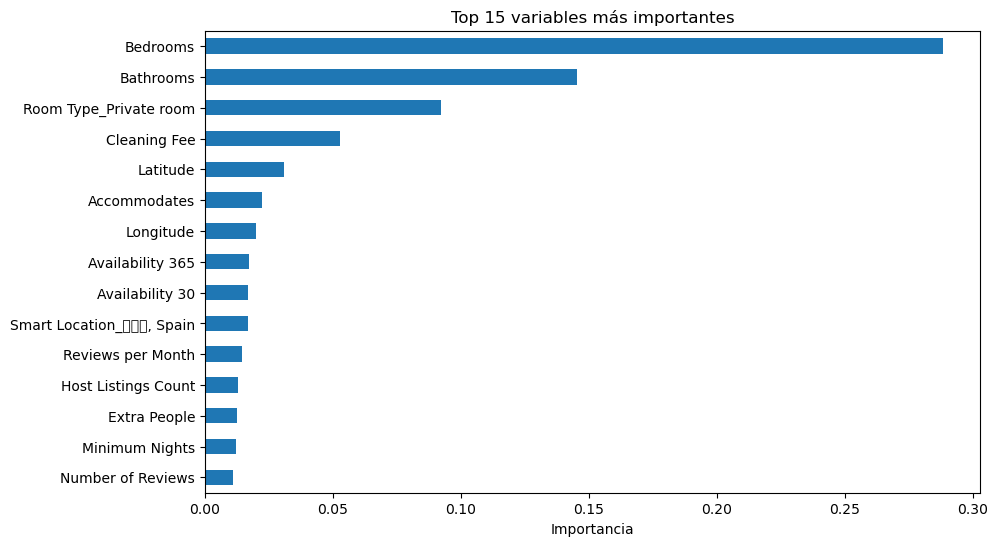

In [49]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

top_features.sort_values().plot(kind="barh")

plt.title("Top 15 variables más importantes")

plt.xlabel("Importancia")

plt.show()

# Interpretación de variables importantes

A partir del análisis de importancia de variables del modelo Random Forest se observa que las variables más relevantes para predecir el precio son:

- número de habitaciones (`Bedrooms`),
- número de baños (`Bathrooms`),
- tipo de habitación (`Room Type`),
- costo de limpieza (`Cleaning Fee`),
- ubicación geográfica (`Latitude` y `Longitude`),
- y capacidad de huéspedes (`Accommodates`).

Esto sugiere que el precio de los alojamientos depende principalmente de:
- tamaño del inmueble,
- capacidad,
- tipo de hospedaje,
- ubicación,
- y costos adicionales asociados.

También se observa que algunas variables relacionadas con disponibilidad y actividad de reseñas aportan información adicional al modelo, aunque con menor importancia relativa.

# Cross Validation

Se utiliza validación cruzada para estimar el rendimiento promedio de los modelos sobre distintas particiones del conjunto de entrenamiento.

Esto permite obtener una evaluación más robusta y menos dependiente de una única división train/test.

In [50]:
from sklearn.model_selection import cross_val_score

models_cv = {
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "Random Forest": rf_model
}

for model_name, model in models_cv.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    print(f"Modelo: {model_name}")
    print(f"R2 medio: {scores.mean():.4f}")
    print(f"Desviación estándar: {scores.std():.4f}")
    print()

Modelo: Ridge
R2 medio: 0.6313
Desviación estándar: 0.0165

Modelo: Lasso
R2 medio: 0.6089
Desviación estándar: 0.0191

Modelo: Random Forest
R2 medio: 0.7119
Desviación estándar: 0.0211



# Conclusiones

- Se realizó un pipeline completo de limpieza, preprocesamiento y modelado sobre el dataset de Airbnb.

- Durante el análisis exploratorio se identificaron outliers importantes en la variable objetivo `Price`, por lo que se aplicó un filtrado basado en percentiles.

- Se eliminaron variables con:
  - exceso de valores nulos,
  - contenido textual complejo,
  - alta cardinalidad,
  - y multicolinealidad fuerte.

- Las variables numéricas fueron imputadas utilizando la mediana, mientras que las categóricas se imputaron utilizando la moda.

- Las variables categóricas fueron transformadas mediante One-Hot Encoding.

- La regresión lineal clásica presentó una fuerte inestabilidad numérica debido a la alta dimensionalidad y multicolinealidad del dataset.

- Ridge y Lasso lograron estabilizar el problema mediante regularización, mostrando una mejora importante en desempeño.

- En validación cruzada, Random Forest obtuvo el mejor rendimiento promedio, con un R² medio aproximado de 0.71.

- En la evaluación sobre test, Random Forest obtuvo el mejor resultado global, alcanzando aproximadamente:
  - R² ≈ 0.73
  - RMSE ≈ 26.3

- Las variables más importantes para la predicción del precio estuvieron relacionadas con:
  - tamaño del alojamiento,
  - número de baños,
  - tipo de habitación,
  - ubicación,
  - capacidad de huéspedes,
  - disponibilidad,
  - y actividad de reseñas.